# Exercise 01: Pandas Hiring Audit
# Cluster 4 - Pandas and Visualization
# Framework: NIST AI RMF Map function, EU AI Act Annex III
# Case Study: Recruitment AI

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

In [2]:
# Create hiring dataset — 100 applicants
n = 100

data = {
    'gender': ['woman'] * 50 + ['man'] * 50,
    'experience': np.random.randint(1, 15, n),
    'education_score': np.random.randint(60, 100, n),
    'interview_score': np.random.randint(60, 100, n),
}

df = pd.DataFrame(data)
print(df.head(10))
print(f"\nShape: {df.shape}")

  gender  experience  education_score  interview_score
0  woman           7               82               71
1  woman           4               99               98
2  woman          13               80               61
3  woman          11               75               62
4  woman           8               77               96
5  woman          13               83               76
6  woman           5               85               61
7  woman           7               84               61
8  woman          10               88               87
9  woman           3               74               82

Shape: (100, 4)


In [3]:
#Shows the average experience, education score, and interview score grouped by gender
df.groupby('gender').mean()



,experience,education_score,interview_score
gender,,,
man,7.46,81.84,80.94
woman,8.30,79.58,78.62


In [12]:
df['total_score'] = df['experience'] + df['education_score'] + df['interview_score']
df['hired'] = df['total_score'] > 180
print(df.groupby('gender')['hired'].mean() * 100)

gender
man      34.0
woman    30.0
Name: hired, dtype: float64


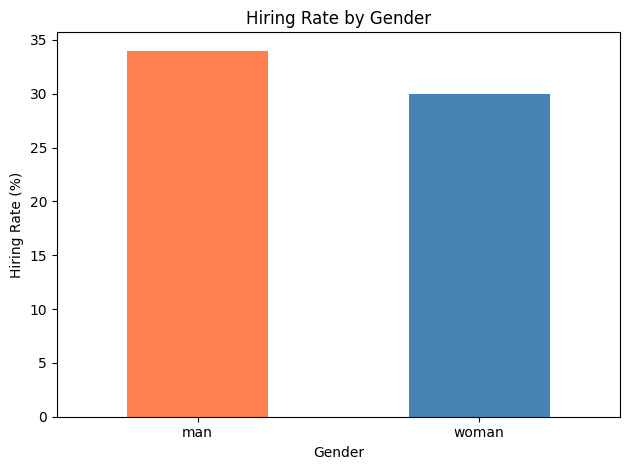

In [14]:
import matplotlib.pyplot as plt

hiring_rates = df.groupby('gender')['hired'].mean() * 100

hiring_rates.plot(kind='bar', color=['coral', 'steelblue'])
plt.title('Hiring Rate by Gender')
plt.ylabel('Hiring Rate (%)')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
print(df.groupby('gender')['total_score'].mean())

gender
man      170.24
woman    166.50
Name: total_score, dtype: float64


In [16]:
print(df.groupby('gender')[['experience', 'education_score', 'interview_score', 'total_score']].mean().round(2))

        experience  education_score  interview_score  total_score
gender                                                           
man           7.46            81.84            80.94       170.24
woman         8.30            79.58            78.62       166.50


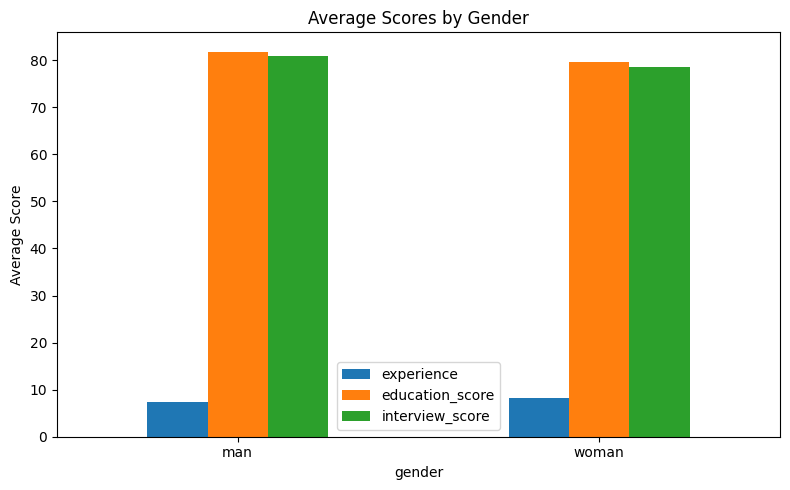

In [17]:
import matplotlib.pyplot as plt

# Bar chart comparing men vs women across all attributes
df.groupby('gender')[['experience', 'education_score', 'interview_score']].mean().plot(
    kind='bar', 
    figsize=(8,5),
    title='Average Scores by Gender'
)
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Exercise 01: Pandas Hiring Audit — Governance Reflection
- NumPy works with matrices and vectors — abstract numerical arrays. But real-world hiring data isn't abstract. It has names, categories, and context.   Pandas lets you work with named columns and rows — like a spreadsheet — making it possible to audit real hiring datasets the way auditors actually     work. You can directly group by gender, compare averages, and see patterns without converting data into abstract vectors first.
- The threshold of 180 matters because it determines who gets hired. At threshold 180, both men and women qualify proportionally (30% women, 34% men)    showing no statistical disparate impact. But if a company raises the threshold to 200 "to hire only the best," suddenly only 4% of women qualify       while 0% of men qualify. This reversal reveals that threshold-setting is a hidden governance choice — different thresholds produce opposite outcomes.
- The education/interview gap is concerning even though it doesn't trigger the 80% rule because it reveals potential bias in how scores are assigned.    Men score higher on education and interview despite having less experience. This could reflect interviewer bias, unequal educational access for        women, or systemic discrimination in how these scores are calculated. These gaps don't appear in the data as illegal disparate impact — but they       signal governance problems worth investigating.
- This connects to NIST AI RMF Map function — you must understand your system before you can measure or manage it. By visualizing and grouping the       data by gender, you reveal hidden patterns (experience vs education/interview tradeoffs, threshold effects) that raw numbers alone wouldn't show.      Mapping means seeing the full picture.

